In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("C:/Data Analyst Projects/08_Financial_Performance_Analytics/Raw_Data/IoT_Financial_Management_Dataset.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (8900, 39)


,Transaction_ID,Branch_ID,Device_ID,Region,Department,Smart_Terminal_Usage,ERP_Response_Time_ms,Network_Latency_ms,Sensor_Data_Integrity,Connected_Devices_Count,...,Transaction_Cost,Automation_Efficiency,Fraud_Risk_Score,Credit_Risk_Level,Security_Breach_Attempts,Compliance_Score,Market_Volatility_Index,Anomaly_Score,Performance_Score,Financial_Status
0,TXN100000,1051,DEV5000,East,Treasury,89.76,147.88,23.34,95.18,37,...,7.17,51.41,0.689,0.366,2,81.47,57.51,0.622,47.08,Poor
1,TXN100001,1092,DEV5001,North,Accounts,96.91,91.54,25.34,90.20,255,...,9.51,67.62,0.039,0.231,4,66.29,59.27,0.286,98.00,Excellent
2,TXN100002,1014,DEV5002,East,Treasury,95.34,150.63,24.47,95.36,110,...,51.75,66.69,0.870,0.163,19,66.94,43.93,0.957,68.40,Moderate
3,TXN100003,1071,DEV5003,North,Investment,58.59,84.40,11.17,86.73,139,...,116.88,95.16,0.397,0.292,13,81.64,54.07,0.973,89.27,Excellent
4,TXN100004,1060,DEV5004,South,Investment,91.51,85.19,38.42,80.26,248,...,7.53,56.31,0.064,0.588,9,83.48,54.72,0.566,96.21,Excellent


In [3]:
# Missing Values & Duplicates Verification

print("--- Missing Values Count ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
if missing_values.sum() == 0:
    print("No missing values found!")

# Check for duplicate rows

print("\n--- Duplicate Rows Count ---")
print("Total Duplicates:", df.duplicated().sum())

--- Missing Values Count ---
Series([], dtype: int64)
No missing values found!

--- Duplicate Rows Count ---
Total Duplicates: 0


In [4]:
# Check unique values in categorical columns
print("Unique Regions:", df['Region'].unique())
print("Unique Departments:", df['Department'].unique())
print("Unique Financial Statuses:", df['Financial_Status'].unique())

Unique Regions: <StringArray>
['East', 'North', 'South', 'West', 'Central']
Length: 5, dtype: str
Unique Departments: <StringArray>
['Treasury', 'Accounts', 'Investment', 'Audit', 'Risk', 'Operations']
Length: 6, dtype: str
Unique Financial Statuses: <StringArray>
['Poor', 'Excellent', 'Moderate', 'Good']
Length: 4, dtype: str


In [6]:
import os

# Create directory to save processed datasets
os.makedirs('processed_data', exist_ok=True)

# 1. Dim_Region Table
dim_region = df[['Region']].drop_duplicates().reset_index(drop=True)
dim_region['Region_ID'] = ['REG_' + str(100 + i) for i in dim_region.index]
dim_region = dim_region[['Region_ID', 'Region']]

# 2. Dim_Department Table
dim_department = df[['Department']].drop_duplicates().reset_index(drop=True)
dim_department['Department_ID'] = ['DEP_' + str(100 + i) for i in dim_department.index]
dim_department = dim_department[['Department_ID', 'Department']]

# 3. Dim_Financial_Status Table
dim_status = df[['Financial_Status']].drop_duplicates().reset_index(drop=True)
dim_status['Status_ID'] = ['STA_' + str(100 + i) for i in dim_status.index]
dim_status = dim_status[['Status_ID', 'Financial_Status']]

# 4. Fact_Financials Table (Merge IDs and Drop Original Categorical Columns)
fact_table = df.copy()
fact_table = fact_table.merge(dim_region, on='Region', how='left')
fact_table = fact_table.merge(dim_department, on='Department', how='left')
fact_table = fact_table.merge(dim_status, on='Financial_Status', how='left')

# Drop original textual columns to keep Fact table normalized
fact_table = fact_table.drop(columns=['Region', 'Department', 'Financial_Status'])

# Reorder columns to put Foreign Keys upfront
fk_cols = ['Transaction_ID', 'Branch_ID', 'Device_ID', 'Region_ID', 'Department_ID', 'Status_ID']
other_cols = [c for c in fact_table.columns if c not in fk_cols]
fact_table = fact_table[fk_cols + other_cols]

# Save all normalized tables to CSV files
dim_region.to_csv('processed_data/Dim_Region.csv', index=False)
dim_department.to_csv('processed_data/Dim_Department.csv', index=False)
dim_status.to_csv('processed_data/Dim_Status.csv', index=False)
fact_table.to_csv('processed_data/Fact_Financials.csv', index=False)

print("--- Star Schema Tables Exported Successfully ---")
print("Fact_Financials Shape:", fact_table.shape)
print("Dim_Region Rows:", len(dim_region))
print("Dim_Department Rows:", len(dim_department))
print("Dim_Status Rows:", len(dim_status))

--- Star Schema Tables Exported Successfully ---
Fact_Financials Shape: (8900, 39)
Dim_Region Rows: 5
Dim_Department Rows: 6
Dim_Status Rows: 4


================ CORE FINANCIAL KPIS ================
Total Revenue        : $4,667.65M  ($4.67B)
Total Net Profit     : $1,364.12M  ($1.36B)
Total Operating Cost : $2,293.34M  ($2.29B)
Average Gross Margin : 37.86%

--- Department Performance Breakdown ($ Millions) ---


,Department,Total_Revenue,Total_Profit,Avg_Margin
2,Investment,$776.36M,$235.36M,38.01%
1,Audit,$801.42M,$234.99M,38.01%
0,Accounts,$794.55M,$228.41M,37.84%
5,Treasury,$789.72M,$225.76M,37.55%
4,Risk,$742.27M,$220.65M,37.26%
3,Operations,$763.34M,$218.95M,38.47%


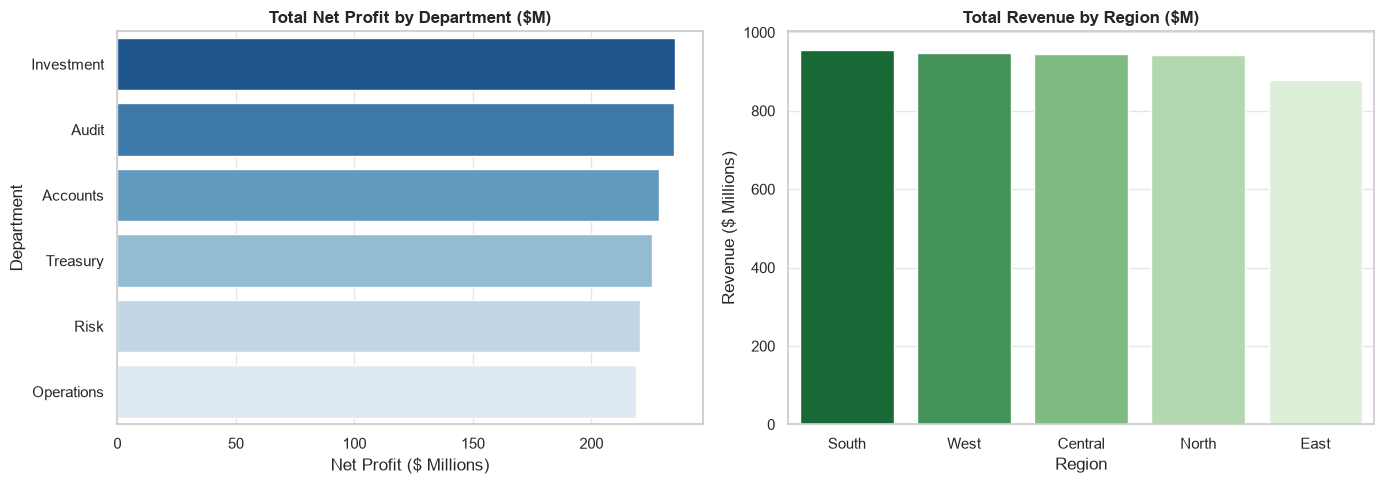

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Overall Key Financial KPIs (Formatted in Millions/Billions with 2 Decimals)
total_revenue = df['Revenue'].sum()
total_profit = df['Net_Profit'].sum()
total_operating_cost = df['Operating_Cost'].sum()
avg_gross_margin = df['Gross_Margin'].mean()

print("================ CORE FINANCIAL KPIS ================")
print(f"Total Revenue        : ${total_revenue / 1e6:,.2f}M  (${total_revenue / 1e9:.2f}B)")
print(f"Total Net Profit     : ${total_profit / 1e6:,.2f}M  (${total_profit / 1e9:.2f}B)")
print(f"Total Operating Cost : ${total_operating_cost / 1e6:,.2f}M  (${total_operating_cost / 1e9:.2f}B)")
print(f"Average Gross Margin : {avg_gross_margin:.2f}%")
print("=====================================================\n")

# 2. Department-wise Financial Performance (Values in $ Millions)
print("--- Department Performance Breakdown ($ Millions) ---")
dept_analysis = df.groupby('Department').agg(
    Total_Revenue=('Revenue', lambda x: x.sum() / 1e6),
    Total_Profit=('Net_Profit', lambda x: x.sum() / 1e6),
    Avg_Margin=('Gross_Margin', 'mean')
).reset_index().sort_values(by='Total_Profit', ascending=False)

# Formatting output to 2 decimal places with $M suffix
dept_analysis['Total_Revenue'] = dept_analysis['Total_Revenue'].map('${:,.2f}M'.format)
dept_analysis['Total_Profit'] = dept_analysis['Total_Profit'].map('${:,.2f}M'.format)
dept_analysis['Avg_Margin'] = dept_analysis['Avg_Margin'].map('{:.2f}%'.format)

display(dept_analysis)

# 3. Visual Charts (Clean & Warning-Free)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Data Preparation (Converted to Millions for Chart Axes)
dept_chart_df = df.groupby('Department')['Net_Profit'].sum().reset_index()
dept_chart_df['Net_Profit_M'] = dept_chart_df['Net_Profit'] / 1e6
dept_chart_df = dept_chart_df.sort_values('Net_Profit_M', ascending=False)

region_chart_df = df.groupby('Region')['Revenue'].sum().reset_index()
region_chart_df['Revenue_M'] = region_chart_df['Revenue'] / 1e6
region_chart_df = region_chart_df.sort_values('Revenue_M', ascending=False)

# Chart 1: Profit by Department ($ Millions)
sns.barplot(data=dept_chart_df, x='Net_Profit_M', y='Department', hue='Department', palette='Blues_r', legend=False, ax=axes[0])
axes[0].set_title('Total Net Profit by Department ($M)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Net Profit ($ Millions)')

# Chart 2: Revenue by Region ($ Millions)
sns.barplot(data=region_chart_df, x='Region', y='Revenue_M', hue='Region', palette='Greens_r', legend=False, ax=axes[1])
axes[1].set_title('Total Revenue by Region ($M)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Revenue ($ Millions)')

plt.tight_layout()
plt.show()